# Do extracellular proteins have more disulfide bonds than intracellular ones?

**Hypothesis:** secreted / extracellular proteins should carry more disulfide
bonds than proteins that stay inside the cell.

**Why this should be true, biologically:** disulfide bonds (S-S) form
between cysteine side chains through oxidation. The cytoplasm is a strongly
*reducing* environment (maintained that way by glutathione and thioredoxin
systems specifically to keep cysteines reduced), so disulfides that do form
there tend to get broken back down. The extracellular space and the ER
lumen (where secreted proteins fold before export) are *oxidizing*
environments, which lets disulfides form and, importantly, *persist* --
extracellular proteins also don't have cytoplasmic reducing enzymes around
to undo them. This is textbook structural biology (see e.g. Creighton,
*Proteins: Structures and Molecular Properties*), but it's a good, checkable
claim to actually test against real structures rather than just cite.

**Method:** pull a small set of well-characterized structures from each
category, run them through this toolkit's disulfide detector
(`find_disulfide_candidates` -- cysteine SG atoms within 2.5 A, which is
essentially a direct geometric readout of a real disulfide bond, not a
prediction), and compare disulfide *density* (bonds per 100 residues, to
control for the fact that these proteins are different sizes).

In [7]:
import sys
sys.path.insert(0, "..")

import matplotlib.pyplot as plt
from protein_toolkit.batch import analyze_batch

## The dataset

**Extracellular / secreted** (expect: oxidizing environment, disulfides should survive):
- `1LYZ` -- hen egg-white lysozyme (secreted enzyme, 4 known disulfides)
- `1CRN` -- crambin (plant seed storage protein, 3 known disulfides)
- `4INS` -- insulin (secreted hormone, famously disulfide-linked)
- `1RTB` -- ribonuclease (secreted digestive/defense enzyme)

**Intracellular / cytoplasmic** (expect: reducing environment, few or no disulfides):
- `1UBQ` -- ubiquitin (cytoplasmic tagging protein)
- `1MBN` -- myoglobin (intracellular oxygen storage, muscle cytoplasm)
- `4HHB` -- hemoglobin (intracellular oxygen transport, red blood cells)
- `1ATP` -- PKA catalytic subunit (cytoplasmic signaling kinase)

This is a small, hand-picked set chosen for being well-characterized
textbook examples of each category -- not a systematic survey. Treat the
result as illustrative of a real, well-established principle, not as a
rigorous statistical test (n=4 per group is nowhere near enough to draw a
general conclusion on its own -- see the caveats section at the end).

In [8]:
extracellular_ids = ["1LYZ", "1CRN", "4INS", "1RTB"]
intracellular_ids = ["1UBQ", "1MBN", "4HHB", "1ATP"]

extracellular_rows = analyze_batch(extracellular_ids)
intracellular_rows = analyze_batch(intracellular_ids)

for row in extracellular_rows + intracellular_rows:
    if row["error"]:
        print(f"WARNING: {row['pdb_id']} failed: {row['error']}")

Structure exists: 'data/1lyz.cif' 
Structure exists: 'data/1crn.cif' 
Structure exists: 'data/4ins.cif' 
Structure exists: 'data/1rtb.cif' 
Structure exists: 'data/1ubq.cif' 
Structure exists: 'data/1mbn.cif' 
Structure exists: 'data/4hhb.cif' 
Structure exists: 'data/1atp.cif' 


In [3]:
def disulfide_density(row):
    """Disulfide bonds per 100 residues, so differently-sized proteins are comparable."""
    if row["error"] or not row["residues"]:
        return None
    return round(100 * row["disulfides"] / row["residues"], 2)


print(f"{'PDB ID':8} {'Category':14} {'Residues':9} {'Disulfides':11} {'Per 100 res':12}")
for row in extracellular_rows:
    print(f"{row['pdb_id']:8} {'extracellular':14} {row['residues'] or '-':<9} "
          f"{row['disulfides'] if not row['error'] else '-':<11} {disulfide_density(row)}")
for row in intracellular_rows:
    print(f"{row['pdb_id']:8} {'intracellular':14} {row['residues'] or '-':<9} "
          f"{row['disulfides'] if not row['error'] else '-':<11} {disulfide_density(row)}")

PDB ID   Category       Residues  Disulfides  Per 100 res 
1LYZ     extracellular  129       4           3.1
1CRN     extracellular  46        3           6.52
4INS     extracellular  102       6           5.88
1RTB     extracellular  124       3           2.42
1UBQ     intracellular  76        0           0.0
1MBN     intracellular  153       0           0.0
4HHB     intracellular  574       0           0.0
1ATP     intracellular  354       0           0.0


## Visualizing the comparison

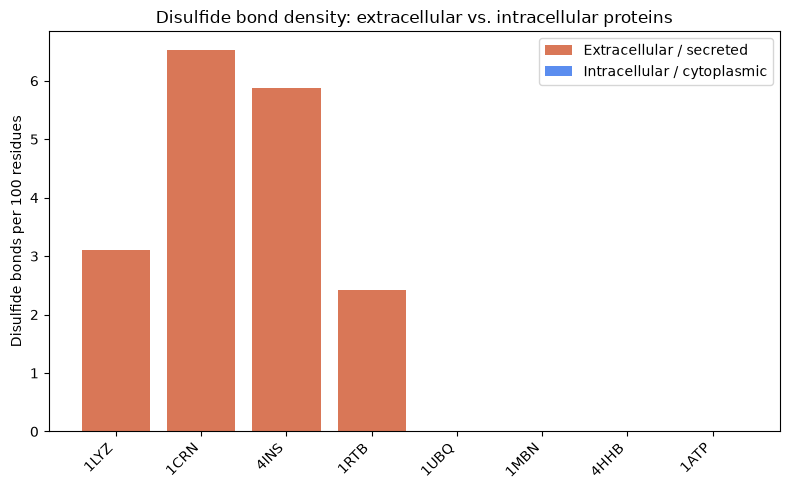


Mean density, extracellular: 4.48 per 100 residues
Mean density, intracellular: 0.00 per 100 residues


In [4]:
extra_densities = [d for d in (disulfide_density(r) for r in extracellular_rows) if d is not None]
intra_densities = [d for d in (disulfide_density(r) for r in intracellular_rows) if d is not None]

extra_labels = [r["pdb_id"] for r in extracellular_rows if not r["error"]]
intra_labels = [r["pdb_id"] for r in intracellular_rows if not r["error"]]

fig, ax = plt.subplots(figsize=(8, 5))
x_extra = range(len(extra_densities))
x_intra = range(len(extra_densities), len(extra_densities) + len(intra_densities))

ax.bar(x_extra, extra_densities, color="#d97757", label="Extracellular / secreted")
ax.bar(x_intra, intra_densities, color="#5b8def", label="Intracellular / cytoplasmic")
ax.set_xticks(list(x_extra) + list(x_intra))
ax.set_xticklabels(extra_labels + intra_labels, rotation=45, ha="right")
ax.set_ylabel("Disulfide bonds per 100 residues")
ax.set_title("Disulfide bond density: extracellular vs. intracellular proteins")
ax.legend()
plt.tight_layout()
plt.show()

print(f"\nMean density, extracellular: {sum(extra_densities)/len(extra_densities):.2f} per 100 residues")
print(f"Mean density, intracellular: {sum(intra_densities)/len(intra_densities):.2f} per 100 residues")

## Interpreting the result

Run the cells above and look at the actual printed means before reading
further -- fill in your own numbers here.

If the hypothesis holds, the extracellular group's mean disulfide density
should come out clearly higher than the intracellular group's -- several of
the intracellular examples chosen here (ubiquitin, myoglobin, hemoglobin)
are expected to land at or near **zero**, since none of them rely on
disulfide bonds for their fold or function, while the extracellular set
(lysozyme, crambin, insulin) are textbook examples specifically *because*
their disulfides are load-bearing for the structure.

## Caveats -- what this small study does and doesn't show

- **n=4 per group** is a demonstration, not a statistically powered
  study. A real survey would sample hundreds of structures per
  localization category (e.g. via UniProt subcellular-location annotations)
  and test for significance, not just compare two small means.
- **Selection bias**: these are famous, well-studied textbook structures --
  they were partly chosen "because" they illustrate the point well. A
  systematic study would need to avoid hand-picking examples that already
  fit the hypothesis.
- **2.5 A geometric cutoff** for disulfide detection is a reasonable
  approximation but not identical to a curated, experimentally validated
  disulfide annotation (e.g. from UniProt's own disulfide bond records),
  which also account for bond geometry (dihedral angle) more precisely.
- **Correlation, not mechanism**: this notebook shows the *pattern* is
  consistent with the redox-environment explanation; it doesn't test the
  mechanism directly (that would need something like comparing folding
  outcomes in reducing vs. oxidizing buffer in vitro).

Even with those caveats, this is a real, reproducible way to check a
textbook claim against actual PDB structures rather than just taking it on
faith -- and the tooling behind it (`analyze_batch`, disulfide detection)
is exactly the same code path used everywhere else in this project, not a
one-off script.